# Week 7 Day 2

# "THE PRICE IS RIGHT" Capstone Project

This week - fine tune an open-source model!

A model that can estimate how much something costs, from its description.

# Order of play

DAY 1: QLoRA  
DAY 2: Prompt data and Base Model  
DAY 3: Train Part 1  
DAY 4: Train Part 2  
DAY 5: Eval 

## First we need to upload the final dataset



In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt


In [4]:
LITE_MODE = False

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

README.md:   0%|          | 0.00/744 [00:00<?, ?B/s]

c:\Users\genon\Downloads\AKA\ori\llm_engineering\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\genon\.cache\huggingface\hub\datasets--ed-donner--items_full. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling ba

train-00000-of-00001.parquet:   0%|          | 0.00/243M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


validation-00000-of-00001.parquet:   0%|          | 0.00/3.04M [00:00<?, ?B/s]

...

test-00000-of-00001.parquet:   0%|          | 0.00/3.04M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


In [5]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

c:\Users\genon\Downloads\AKA\ori\llm_engineering\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\genon\.cache\huggingface\hub\models--meta-llama--Llama-3.2-3B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

In [6]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

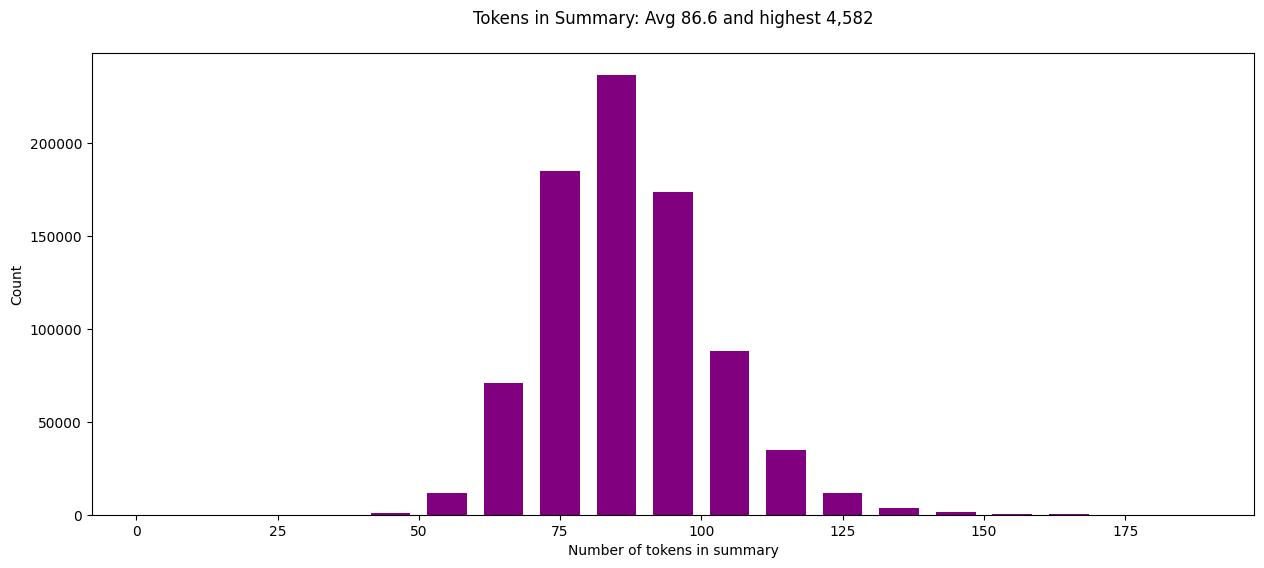

In [7]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="purple", bins=range(0, 200, 10))
plt.show()

In [8]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")


With this CUTOFF, we will truncate 47,083 items which is 5.7%


In [9]:
print(train[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


In [10]:
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/810000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [11]:
print("PROMPT:")
print(test[0].prompt)
print("COMPLETION:")
print(test[0].completion)


PROMPT:
What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.

Price is $
COMPLETION:
219.0


In [12]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

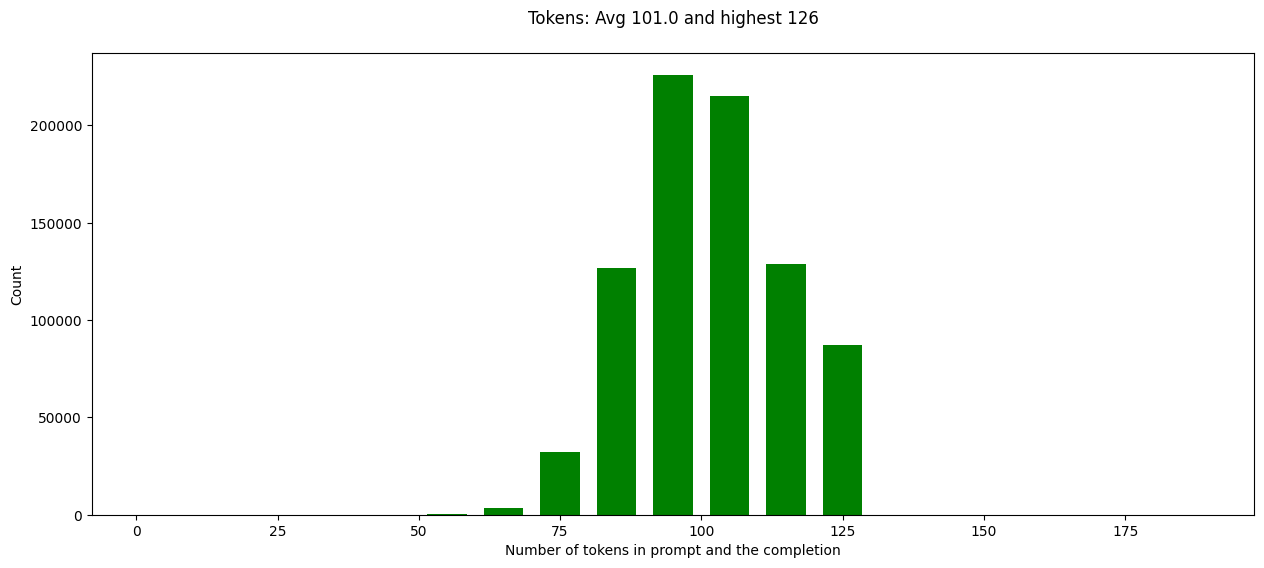

In [15]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="green", bins=range(0, 200, 10))
plt.show()

In [16]:
username = "muhammad17azka"
dataset = f"{username}/items_prompts_lite" if LITE_MODE else f"{username}/items_prompts_full"

Item.push_prompts_to_hub(dataset, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/800 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Here are the datasets in HuggingFace:

https://huggingface.co/datasets/ed-donner/items_prompts_lite

https://huggingface.co/datasets/ed-donner/items_prompts_full

Please see this notebook in Google Colab:

https://colab.research.google.com/drive/1wO3lNMrMfprlJZF4X9fSsQ8tYC3SRZbh?usp=sharing